# PINN for a 2D compressible Neo-Hookean solid

This notebook solves a forward hyperelasticity problem on the reference square

$$
\Omega_0=[0,1]^2.
$$

The manufactured displacement is

$$
\mathbf u(X,Y)=
\begin{bmatrix}
0.1(X^2+Y^2)\\
0.05Y^2
\end{bmatrix}.
$$

The material parameters are

$$
E=1000,
\qquad
\nu=0.3.
$$

A Neo-Hookean plane-strain model is used:

$$
W(\mathbf F)
=\frac{\mu}{2}(I_1-2)-\mu\ln J
+\frac{\lambda}{2}(\ln J)^2,
$$

$$
\mathbf F=\mathbf I+\nabla_X\mathbf u,
\qquad
J=\det\mathbf F,
\qquad
I_1=\operatorname{tr}(\mathbf F^{\mathsf T}\mathbf F).
$$

The first Piola--Kirchhoff stress and equilibrium equation are

$$
\mathbf P
=\mu(\mathbf F-\mathbf F^{-\mathsf T})
+\lambda\ln J\,\mathbf F^{-\mathsf T},
\qquad
\operatorname{Div}_X\mathbf P+\mathbf B=\mathbf0.
$$

The body force is manufactured from the exact displacement. Training points update the network, validation points select the best checkpoint, and test points are used only for the final evaluation.


## 1. Imports


In [53]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

OUTPUT_DIR = Path("imgs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 2. Settings

The training workflow follows the 1D reference notebook. The material is interpreted as a plane-strain reduction of a three-dimensional compressible Neo-Hookean solid. A small orientation-preserving penalty is included if the predicted determinant approaches zero.


In [ ]:
USE_DATA = False
DATA_MODE = "exact"
NOISE_RELATIVE_STD = 0.02
assert DATA_MODE in {"exact", "noisy"}

L = 1.0
E_YOUNG = 1000.0
POISSON_RATIO = 0.3
MU = E_YOUNG / (2.0 * (1.0 + POISSON_RATIO))
LAME_LAMBDA = (
    E_YOUNG * POISSON_RATIO
    / ((1.0 + POISSON_RATIO) * (1.0 - 2.0 * POISSON_RATIO))
)

N_SIDE_PDE_TRAIN = 35
N_SIDE_PDE_VALIDATION = 12
N_SIDE_PDE_TEST = 12
PDE_BATCH_SIZE = 32
N_BOUNDARY_PER_EDGE = 40

N_DATA_TRAIN = 50
N_DATA_VALIDATION = 20
N_DATA_TEST = 20

EPOCHS = 2000
LBFGS_EPOCHS = 100
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
LR = 1e-3
SEED = 42
WEIGHT = 1e-6

torch.manual_seed(SEED)
print(f"Young's modulus: {E_YOUNG:.1f}")
print(f"Poisson ratio: {POISSON_RATIO:.3f}")
print(f"Lamé lambda: {LAME_LAMBDA:.6f}")
print(f"Shear modulus mu: {MU:.6f}")
print(f"Displacement data mode: {DATA_MODE}")
if DATA_MODE == "noisy":
    print(f"Relative noise standard deviation: {NOISE_RELATIVE_STD:.1%}")


Young's modulus: 1000.0
Poisson ratio: 0.300
Lamé lambda: 576.923077
Shear modulus mu: 384.615385
Displacement data mode: exact


## 3. Exact solution, boundary conditions, and body force

The exact displacement is

$$
\mathbf u(X,Y)=
\begin{bmatrix}
0.1(X^2+Y^2)\\
0.05Y^2
\end{bmatrix}.
$$

The deformation gradient is

$$
\mathbf F(X,Y)=
\begin{bmatrix}
1+0.2X & 0.2Y\\
0 & 1+0.1Y
\end{bmatrix},
\qquad
J=(1+0.2X)(1+0.1Y)>0.
$$

Dirichlet conditions are prescribed on the complete boundary:

$$
\mathbf u(0,Y)=
\begin{bmatrix}0.1Y^2\\0.05Y^2\end{bmatrix},
\qquad
\mathbf u(1,Y)=
\begin{bmatrix}0.1(1+Y^2)\\0.05Y^2\end{bmatrix},
$$

$$
\mathbf u(X,0)=
\begin{bmatrix}0.1X^2\\0\end{bmatrix},
\qquad
\mathbf u(X,1)=
\begin{bmatrix}0.1(X^2+1)\\0.05\end{bmatrix}.
$$

The manufactured reference body force is

$$
\mathbf B=-\operatorname{Div}_X\mathbf P_{\mathrm{exact}}.
$$


In [ ]:
def exact_displacement(xy):
    X = xy[:, 0:1]
    Y = xy[:, 1:2]
    ux = 0.1 * (X**2 + Y**2)
    uy = 0.05 * Y**2
    return torch.cat((ux, uy), dim=1)


def exact_deformation_gradient(xy):
    X = xy[:, 0:1]
    Y = xy[:, 1:2]
    row_1 = torch.cat((1.0 + 0.2 * X, 0.2 * Y), dim=1)
    row_2 = torch.cat((torch.zeros_like(X), 1.0 + 0.1 * Y), dim=1)
    return torch.stack((row_1, row_2), dim=1)


def first_piola_from_F(F):
    J = torch.linalg.det(F)
    J_safe = torch.clamp(J, min=1e-8)
    inverse_transpose = torch.linalg.inv(F).transpose(1, 2)
    logarithmic_term = torch.log(J_safe).view(-1, 1, 1)
    P = (MU * (F - inverse_transpose) + LAME_LAMBDA * logarithmic_term * inverse_transpose)
    return P, J


def exact_nominal_stress(xy):
    P, _ = first_piola_from_F(exact_deformation_gradient(xy))
    return P


def body_force(xy):
    X = xy[:, 0:1]
    Y = xy[:, 1:2]
    a = 1.0 + 0.2 * X
    b = 0.2 * Y
    c = 1.0 + 0.1 * Y
    q = LAME_LAMBDA * torch.log(a * c) - MU

    divergence_x = 0.4 * MU + 0.2 * (LAME_LAMBDA - q) / a**2
    divergence_y = (0.1 * MU + 0.1 * (LAME_LAMBDA - q) / c**2 - 0.2 * b * (LAME_LAMBDA - q) / (c * a**2))
    return -torch.cat((divergence_x, divergence_y), dim=1)


def observed_displacement(xy, seed):
    exact = exact_displacement(xy)
    if DATA_MODE == "exact":
        return exact

    component_scales = torch.tensor([[0.2, 0.05]], dtype=exact.dtype)
    generator = torch.Generator().manual_seed(seed)
    noise = torch.randn(exact.shape, generator=generator, dtype=exact.dtype)
    return exact + NOISE_RELATIVE_STD * component_scales * noise


## 4. Neural network


In [56]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 10),
            nn.Tanh(),
            nn.Linear(10, 10),
            nn.Tanh(),
            nn.Linear(10, 10),
            nn.Tanh(),
            nn.Linear(10, 2),
        )


    def forward(self, xy):
        return self.net(xy)


model = PINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")


Trainable parameters: 272


## 5. PDE train, validation, and test points

All three PDE sets are uniform interior Cartesian grids with different within-cell shifts. The shifts make the training, validation, and test coordinates mutually disjoint. Training points update the network, validation points select the best checkpoint, and test points remain unused until the final evaluation.


In [57]:
def shifted_uniform_grid_2d(n_side, shift_x, shift_y):
    indices = torch.arange(n_side, dtype=torch.get_default_dtype())
    x = L * (indices + shift_x) / n_side
    y = L * (indices + shift_y) / n_side
    X, Y = torch.meshgrid(x, y, indexing="xy")
    return torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)


def grids_overlap(first, second):
    differences = torch.abs(first[:, None, :] - second[None, :, :])
    identical = torch.all(differences < 1e-12, dim=2)
    return bool(torch.any(identical))


x_pde_train = shifted_uniform_grid_2d(N_SIDE_PDE_TRAIN, shift_x=0.50, shift_y=0.50)
x_pde_validation = shifted_uniform_grid_2d(N_SIDE_PDE_VALIDATION, shift_x=0.37, shift_y=0.61)
x_pde_test = shifted_uniform_grid_2d(N_SIDE_PDE_TEST, shift_x=0.73, shift_y=0.29)

assert not grids_overlap(x_pde_train, x_pde_validation)
assert not grids_overlap(x_pde_train, x_pde_test)
assert not grids_overlap(x_pde_validation, x_pde_test)

print(
    f"PDE points: {len(x_pde_train)} train, "
    f"{len(x_pde_validation)} validation, {len(x_pde_test)} test"
)
print("PDE grids overlap: False")
print(f"Adam PDE batch size: {PDE_BATCH_SIZE}")

pde_batch_generator = torch.Generator().manual_seed(SEED + 1)
pde_train_loader = DataLoader(TensorDataset(x_pde_train), batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_batch_generator,)


PDE points: 1225 train, 144 validation, 144 test
PDE grids overlap: False
Adam PDE batch size: 32


## 6. Dirichlet boundary points and optional supervised data

All four edges use the exact nonhomogeneous Dirichlet values. Boundary points and the small optional displacement dataset are used in every optimizer step and are not included in the PDE mini-batches.

Set `DATA_MODE` to `"exact"` or `"noisy"`. In noisy mode, independent Gaussian noise is added to the train, validation, and test displacement observations. Boundary values remain exact.


In [ ]:
edge_coordinate = torch.linspace(0.0, L, N_BOUNDARY_PER_EDGE).view(-1, 1)
zeros = torch.zeros_like(edge_coordinate)
ones = torch.ones_like(edge_coordinate)

xy_boundary = torch.cat(
    (torch.cat((zeros, edge_coordinate), dim=1),
    torch.cat((ones, edge_coordinate), dim=1),
    torch.cat((edge_coordinate, zeros), dim=1),
    torch.cat((edge_coordinate, ones), dim=1),),
    dim=0,)
u_boundary = exact_displacement(xy_boundary)


if USE_DATA:
    train_generator = torch.Generator().manual_seed(SEED + 10)
    validation_generator = torch.Generator().manual_seed(SEED + 11)
    test_generator = torch.Generator().manual_seed(SEED + 12)

    xy_data_train = L * torch.rand(N_DATA_TRAIN, 2, generator=train_generator)
    xy_data_validation = L * torch.rand(N_DATA_VALIDATION, 2, generator=validation_generator)
    xy_data_test = L * torch.rand(N_DATA_TEST, 2, generator=test_generator)

    u_data_train = observed_displacement(xy_data_train, seed=SEED + 20)
    u_data_validation = observed_displacement(xy_data_validation, seed=SEED + 21)
    u_data_test = observed_displacement(xy_data_test, seed=SEED + 22)

    print(
        f"Displacement data: {N_DATA_TRAIN} train, "
        f"{N_DATA_VALIDATION} validation, {N_DATA_TEST} test"
    )
    print(f"Displacement data mode: {DATA_MODE}")

print(f"Dirichlet boundary points: {len(xy_boundary)}")


Dirichlet boundary points: 160


## 7. Physics residual and training

The network approximates

$$
\mathbf u_\theta(X,Y)=
\begin{bmatrix}u_{x,\theta}\\u_{y,\theta}\end{bmatrix}.
$$

Automatic differentiation gives

$$
\mathbf F_\theta=\mathbf I+\nabla_X\mathbf u_\theta,
\qquad
J_\theta=\det\mathbf F_\theta,
$$

$$
\mathbf P_\theta
=\mu(\mathbf F_\theta-\mathbf F_\theta^{-\mathsf T})
+\lambda\ln J_\theta\,\mathbf F_\theta^{-\mathsf T}.
$$

The PDE residual is

$$
\mathbf r_\theta
=\operatorname{Div}_X\mathbf P_\theta+\mathbf B.
$$

The training loss contains the equilibrium residual, all four Dirichlet boundaries, an orientation-preserving penalty, and optional displacement observations. During Adam training, only the PDE points are mini-batched. Boundary points and supervised data are used in every optimizer step. Validation, testing, and L-BFGS use fixed full batches.


In [ ]:
loss_history = []
pde_loss_history = []
bc_loss_history = []
data_loss_history = []
validation_loss_history = []
validation_pde_loss_history = []
validation_data_loss_history = []

best_validation_loss = float("inf")
best_validation_pde_loss = None
best_validation_data_loss = None
best_epoch = None
best_model_state = None


def deformation_gradient_from_displacement(u, xy):
    ux = u[:, 0:1]
    uy = u[:, 1:2]
    grad_ux = torch.autograd.grad(ux, xy, torch.ones_like(ux), create_graph=True, retain_graph=True)[0]
    grad_uy = torch.autograd.grad(uy, xy, torch.ones_like(uy), create_graph=True, retain_graph=True)[0]
    row_1 = torch.cat((1.0 + grad_ux[:, 0:1], grad_ux[:, 1:2]), dim=1)
    row_2 = torch.cat((grad_uy[:, 0:1], 1.0 + grad_uy[:, 1:2]), dim=1)
    return torch.stack((row_1, row_2), dim=1)


def displacement_stress_and_residual(xy, create_graph):
    xy_local = xy.detach().clone().requires_grad_(True)
    u = model(xy_local)
    F = deformation_gradient_from_displacement(u, xy_local)
    P, J = first_piola_from_F(F)

    grad_P11 = torch.autograd.grad(P[:, 0, 0:1], xy_local, torch.ones_like(P[:, 0, 0:1]), create_graph=create_graph, retain_graph=True)[0]
    grad_P12 = torch.autograd.grad(P[:, 0, 1:2], xy_local, torch.ones_like(P[:, 0, 1:2]), create_graph=create_graph, retain_graph=True)[0]
    grad_P21 = torch.autograd.grad(P[:, 1, 0:1], xy_local, torch.ones_like(P[:, 1, 0:1]), create_graph=create_graph, retain_graph=True)[0]
    grad_P22 = torch.autograd.grad(P[:, 1, 1:2], xy_local, torch.ones_like(P[:, 1, 1:2]), create_graph=create_graph, retain_graph=True)[0]

    divergence_x = grad_P11[:, 0:1] + grad_P12[:, 1:2]
    divergence_y = grad_P21[:, 0:1] + grad_P22[:, 1:2]
    divergence = torch.cat((divergence_x, divergence_y), dim=1)
    residual = divergence + body_force(xy_local)
    return u, P, residual, J


def compute_training_losses(xy_pde):
    _, _, residual, J = displacement_stress_and_residual(xy_pde, create_graph=True)
    loss_equilibrium = torch.mean((residual )**2)
    loss_pde = loss_equilibrium

    boundary_error = model(xy_boundary) - u_boundary
    loss_bc = torch.mean(boundary_error**2)

    loss_data = (torch.mean((model(xy_data_train) - u_data_train)**2)
        if USE_DATA else torch.tensor(0.0))
    loss = WEIGHT * loss_pde + loss_bc +  loss_data
    return loss, loss_pde, loss_bc, loss_data


def compute_validation_losses():
    _, _, residual, J = displacement_stress_and_residual(x_pde_validation, create_graph=False)
    loss_equilibrium = torch.mean((residual.detach())**2)
    loss_pde = loss_equilibrium

    with torch.no_grad():
        loss_data = (torch.mean((model(xy_data_validation) - u_data_validation)**2)
            if USE_DATA else torch.tensor(0.0))
    return WEIGHT * loss_pde + loss_data, loss_pde, loss_data


def update_checkpoint(epoch):
    global best_validation_loss, best_validation_pde_loss
    global best_validation_data_loss, best_epoch, best_model_state

    model.eval()
    loss, loss_pde, loss_data = compute_validation_losses()
    values = loss.item(), loss_pde.item(), loss_data.item()
    validation_loss_history.append(values[0])
    validation_pde_loss_history.append(values[1])
    validation_data_loss_history.append(values[2])

    if best_model_state is None or values[0] < best_validation_loss:
        best_validation_loss = values[0]
        best_validation_pde_loss = values[1]
        best_validation_data_loss = values[2]
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())

    model.train()
    return values[0]


for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(4)
    samples = 0

    for (xy_pde_batch,) in pde_train_loader:
        optimizer_adam.zero_grad(set_to_none=True)
        losses = compute_training_losses(xy_pde_batch)
        losses[0].backward()
        optimizer_adam.step()

        batch_size = len(xy_pde_batch)
        epoch_sums += np.array([value.detach().item() for value in losses]) * batch_size
        samples += batch_size

    epoch_values = epoch_sums / samples
    loss_history.append(epoch_values[0])
    pde_loss_history.append(epoch_values[1])
    bc_loss_history.append(epoch_values[2])
    data_loss_history.append(epoch_values[3])
    validation_value = update_checkpoint(epoch)

    if epoch % 100 == 0:
        print(
            f"Adam | epoch {epoch:5d} | loss={epoch_values[0]:.3e} "
            f"| PDE={epoch_values[1]:.3e} | BC={epoch_values[2]:.3e} "
            f"| validation={validation_value:.3e}"
        )


optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=50, line_search_fn="strong_wolfe")

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad(set_to_none=True)
        loss, _, _, _ = compute_training_losses(x_pde_train)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    loss, loss_pde, loss_bc, loss_data = compute_training_losses(x_pde_train)
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())
    validation_value = update_checkpoint(epoch)

    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(
            f"L-BFGS | epoch {epoch:5d} | loss={loss.item():.3e} "
            f"| validation={validation_value:.3e}"
        )


last_model_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_model_state)
model.eval()

print(f"Best epoch: {best_epoch}")
print(f"Best combined validation loss: {best_validation_loss:.6e}")
print(f"Validation PDE loss: {best_validation_pde_loss:.6e}")
print(f"Validation data MSE: {best_validation_data_loss:.6e}")


Adam | epoch     0 | loss=2.191e+02 | PDE=2.190e+04 | BC=6.674e-02 | validation=4.349e+01
Adam | epoch   100 | loss=2.404e-02 | PDE=1.004e+00 | BC=1.400e-02 | validation=1.684e-02
Adam | epoch   200 | loss=1.251e-02 | PDE=3.283e-01 | BC=9.226e-03 | validation=5.241e-03
Adam | epoch   300 | loss=7.809e-03 | PDE=2.248e-01 | BC=5.561e-03 | validation=1.365e-03
Adam | epoch   400 | loss=4.519e-03 | PDE=1.712e-01 | BC=2.808e-03 | validation=2.224e-03
Adam | epoch   500 | loss=2.728e-03 | PDE=1.570e-01 | BC=1.159e-03 | validation=9.658e-04
Adam | epoch   600 | loss=1.171e-03 | PDE=7.424e-02 | BC=4.288e-04 | validation=1.868e-03
Adam | epoch   700 | loss=6.374e-04 | PDE=4.222e-02 | BC=2.152e-04 | validation=1.048e-03
Adam | epoch   800 | loss=1.579e-03 | PDE=1.429e-01 | BC=1.498e-04 | validation=7.057e-04
Adam | epoch   900 | loss=3.429e-04 | PDE=2.143e-02 | BC=1.286e-04 | validation=1.622e-04
Adam | epoch  1000 | loss=7.596e-04 | PDE=6.421e-02 | BC=1.175e-04 | validation=1.090e-03
Adam | epo

## 8. Final test metrics


In [60]:
model.eval()
u_test, P_test, residual_test, J_test = displacement_stress_and_residual(x_pde_test, create_graph=False)

u_test = u_test.detach()
P_test = P_test.detach()
residual_test = residual_test.detach()
J_test = J_test.detach()
u_exact_test = exact_displacement(x_pde_test)
P_exact_test = exact_nominal_stress(x_pde_test)


def relative_l2(prediction, exact):
    return (torch.linalg.vector_norm(prediction - exact) / torch.linalg.vector_norm(exact)).item()


def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact)**2)
    ss_tot = torch.sum((exact - torch.mean(exact))**2)
    return (1.0 - ss_res / ss_tot).item()


with torch.no_grad():
    boundary_mse = torch.mean((model(xy_boundary) - u_boundary)**2).item()

metrics = {
    "best_epoch": best_epoch,
    "best_validation_loss": best_validation_loss,
    "displacement_R2_test": r2_score(u_test, u_exact_test),
    "displacement_relative_L2_test": relative_l2(u_test, u_exact_test),
    "nominal_stress_R2_test": r2_score(P_test, P_exact_test),
    "nominal_stress_relative_L2_test": relative_l2(P_test, P_exact_test),
    "PDE_test_MSE": torch.mean(residual_test**2).item(),
    "boundary_MSE": boundary_mse,
}

print("=" * 62)
print("2D NEO-HOOKEAN PINN TEST RESULTS")
print("=" * 62)
print(f"Displacement R2:              {metrics['displacement_R2_test']:.8f}")
print(f"Displacement relative L2:     {metrics['displacement_relative_L2_test']:.6e}")
print(f"Nominal stress R2:            {metrics['nominal_stress_R2_test']:.8f}")
print(f"Nominal stress relative L2:   {metrics['nominal_stress_relative_L2_test']:.6e}")
print(f"PDE residual MSE:             {metrics['PDE_test_MSE']:.6e}")
print(f"Boundary MSE:                 {metrics['boundary_MSE']:.6e}")
print("=" * 62)

metrics


2D NEO-HOOKEAN PINN TEST RESULTS
Displacement R2:              0.99269003
Displacement relative L2:     5.985992e-02
Nominal stress R2:            0.98261255
Nominal stress relative L2:   8.377997e-02
PDE residual MSE:             1.106290e-03
Boundary MSE:                 2.698860e-05


{'best_epoch': 1934,
 'best_validation_loss': 1.1250660463701934e-05,
 'displacement_R2_test': 0.9926900267601013,
 'displacement_relative_L2_test': 0.05985992029309273,
 'nominal_stress_R2_test': 0.9826125502586365,
 'nominal_stress_relative_L2_test': 0.0837799683213234,
 'PDE_test_MSE': 0.0011062902631238103,
 'boundary_MSE': 2.6988596800947562e-05}

## 9. Plots


In [61]:
def regular_grid(n=60):
    values = torch.linspace(0.0, L, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)
    return X.numpy(), Y.numpy(), xy


def predict_u_and_P(xy, state_dict=None):
    current_state = copy.deepcopy(model.state_dict())
    if state_dict is not None:
        model.load_state_dict(state_dict)
    model.eval()

    xy_local = xy.detach().clone().requires_grad_(True)
    u = model(xy_local)
    F = deformation_gradient_from_displacement(u, xy_local)
    P, J = first_piola_from_F(F)

    model.load_state_dict(current_state)
    model.eval()
    return u.detach(), P.detach(), J.detach()


PLOT_SIDE = 60
X_plot, Y_plot, xy_plot = regular_grid(PLOT_SIDE)
u_best, P_best, J_best = predict_u_and_P(xy_plot, best_model_state)
u_last, P_last, J_last = predict_u_and_P(xy_plot, last_model_state)
u_exact_plot = exact_displacement(xy_plot)
P_exact_plot = exact_nominal_stress(xy_plot)


def plot_data_split():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    axes[0].scatter(x_pde_train[:, 0], x_pde_train[:, 1], s=9,
                    color="tab:blue", alpha=0.45,
                    label=f"train ({len(x_pde_train)})")
    axes[0].scatter(x_pde_validation[:, 0], x_pde_validation[:, 1], s=18,
                    color="tab:green", marker="s",
                    label=f"validation ({len(x_pde_validation)})")
    axes[0].scatter(x_pde_test[:, 0], x_pde_test[:, 1], s=18,
                    color="tab:orange", marker="x",
                    label=f"test ({len(x_pde_test)})")
    axes[0].set(xlabel="X", ylabel="Y", title="PDE collocation points")
    axes[0].set_aspect("equal")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].scatter(xy_boundary[:, 0], xy_boundary[:, 1], s=16,
                    color="black", label="Dirichlet boundary")
    if USE_DATA:
        axes[1].scatter(xy_data_train[:, 0], xy_data_train[:, 1], s=35,
                        color="tab:blue", label=f"data train ({N_DATA_TRAIN})")
        axes[1].scatter(xy_data_validation[:, 0], xy_data_validation[:, 1], s=40,
                        color="tab:green", marker="s",
                        label=f"data validation ({N_DATA_VALIDATION})")
        axes[1].scatter(xy_data_test[:, 0], xy_data_test[:, 1], s=40,
                        color="tab:orange", marker="x",
                        label=f"data test ({N_DATA_TEST})")
    axes[1].set(xlabel="X", ylabel="Y", title=f"Boundary and data ({DATA_MODE})")
    axes[1].set_aspect("equal")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.savefig(OUTPUT_DIR / "hyperelastic_2d_points_and_data.pdf", bbox_inches="tight")
    plt.show()


def plot_field_rows(exact, predicted, names, filename, figure_title):
    number_of_fields = len(names)
    fig, axes = plt.subplots(
        number_of_fields, 3,
        figsize=(13, 3.8 * number_of_fields),
        squeeze=False,
        constrained_layout=True,
    )

    for row, name in enumerate(names):
        exact_field = exact[:, row].reshape(PLOT_SIDE, PLOT_SIDE).numpy()
        predicted_field = predicted[:, row].reshape(PLOT_SIDE, PLOT_SIDE).numpy()
        scale = max(np.max(np.abs(exact_field)), np.finfo(float).eps)
        error_field = np.abs(predicted_field - exact_field) / scale
        common_limit = max(np.max(np.abs(exact_field)), np.max(np.abs(predicted_field)))

        exact_image = axes[row, 0].pcolormesh(
            X_plot, Y_plot, exact_field, shading="auto", cmap="coolwarm",
            vmin=-common_limit, vmax=common_limit)
        axes[row, 1].pcolormesh(
            X_plot, Y_plot, predicted_field, shading="auto", cmap="coolwarm",
            vmin=-common_limit, vmax=common_limit)
        error_image = axes[row, 2].pcolormesh(
            X_plot, Y_plot, error_field, shading="auto", cmap="viridis",
            vmin=0.0)

        titles = [f"Exact {name}", f"PINN {name}", f"Normalized error {name}"]
        for axis, title in zip(axes[row], titles):
            axis.set(title=title, xlabel="X", ylabel="Y")
            axis.set_aspect("equal")
        fig.colorbar(exact_image, ax=axes[row, :2], shrink=0.85)
        fig.colorbar(error_image, ax=axes[row, 2], shrink=0.85)

    fig.suptitle(figure_title)
    fig.savefig(OUTPUT_DIR / filename, bbox_inches="tight")
    plt.show()


def plot_solution():
    plot_field_rows(u_exact_plot, u_best, [r"$u_x$", r"$u_y$"], "hyperelastic_2d_displacement.pdf", "Displacement")

    exact_P_flat = P_exact_plot.reshape(-1, 4)
    predicted_P_flat = P_best.reshape(-1, 4)
    plot_field_rows(exact_P_flat,
        predicted_P_flat, [r"$P_{11}$", r"$P_{12}$", r"$P_{21}$", r"$P_{22}$"], "hyperelastic_2d_first_piola.pdf", "First Piola--Kirchhoff stress")


def plot_losses():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(loss_history, alpha=0.70, label="total")
    axes[0].plot(pde_loss_history, alpha=0.65, label="PDE")
    axes[0].plot(bc_loss_history, alpha=0.65, label="Dirichlet boundary")
    if USE_DATA:
        axes[0].plot(data_loss_history, alpha=0.65, label="supervised data")
    axes[0].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[0].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[0].set_yscale("log")
    axes[0].set(xlabel="epoch", ylabel="loss", title="Training losses")
    axes[0].grid()
    axes[0].legend()

    axes[1].plot(validation_loss_history, alpha=0.70, label="combined validation")
    axes[1].plot(validation_pde_loss_history, alpha=0.65, label="PDE")
    if USE_DATA:
        axes[1].plot(validation_data_loss_history, alpha=0.65, label="data")
    axes[1].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[1].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[1].set_yscale("log")
    axes[1].set(xlabel="epoch", ylabel="loss", title="Validation losses")
    axes[1].grid()
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hyperelastic_2d_losses.pdf", bbox_inches="tight")
    plt.show()


def plot_errors():
    ux_scale = torch.max(torch.abs(u_exact_plot[:, 0])).clamp_min(1e-12)
    uy_scale = torch.max(torch.abs(u_exact_plot[:, 1])).clamp_min(1e-12)
    ux_error = torch.abs(u_best[:, 0] - u_exact_plot[:, 0]) / ux_scale
    uy_error = torch.abs(u_best[:, 1] - u_exact_plot[:, 1]) / uy_scale

    stress_difference = torch.linalg.matrix_norm(P_best - P_exact_plot)
    stress_scale = torch.max(torch.linalg.matrix_norm(P_exact_plot)).clamp_min(1e-12)
    stress_error = stress_difference / stress_scale

    fields = [ux_error, uy_error, stress_error]
    titles = [r"Error in $u_x$", r"Error in $u_y$", r"Error in  $P$"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), constrained_layout=True)
    for axis, field, title in zip(axes, fields, titles):
        image = axis.pcolormesh(
            X_plot, Y_plot,
            field.reshape(PLOT_SIDE, PLOT_SIDE).numpy(),
            shading="auto", cmap="viridis", vmin=0.0,
        )
        axis.set(title=title, xlabel="X", ylabel="Y")
        axis.set_aspect("equal")
        fig.colorbar(image, ax=axis)

    fig.savefig(OUTPUT_DIR / "hyperelastic_2d_errors.pdf", bbox_inches="tight")
    plt.show()


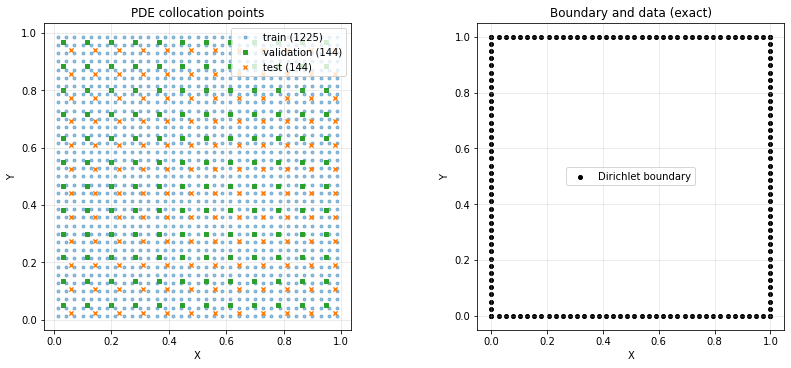

In [62]:
plot_data_split()


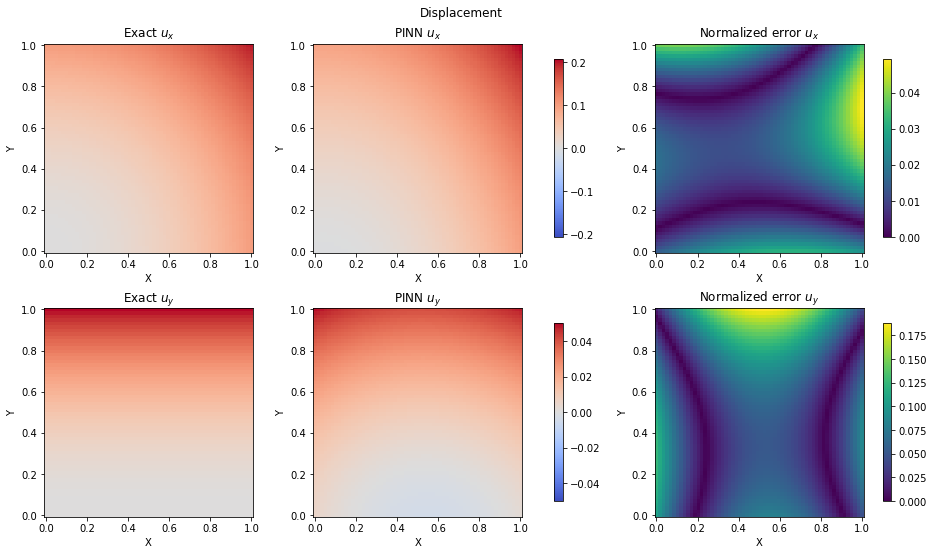

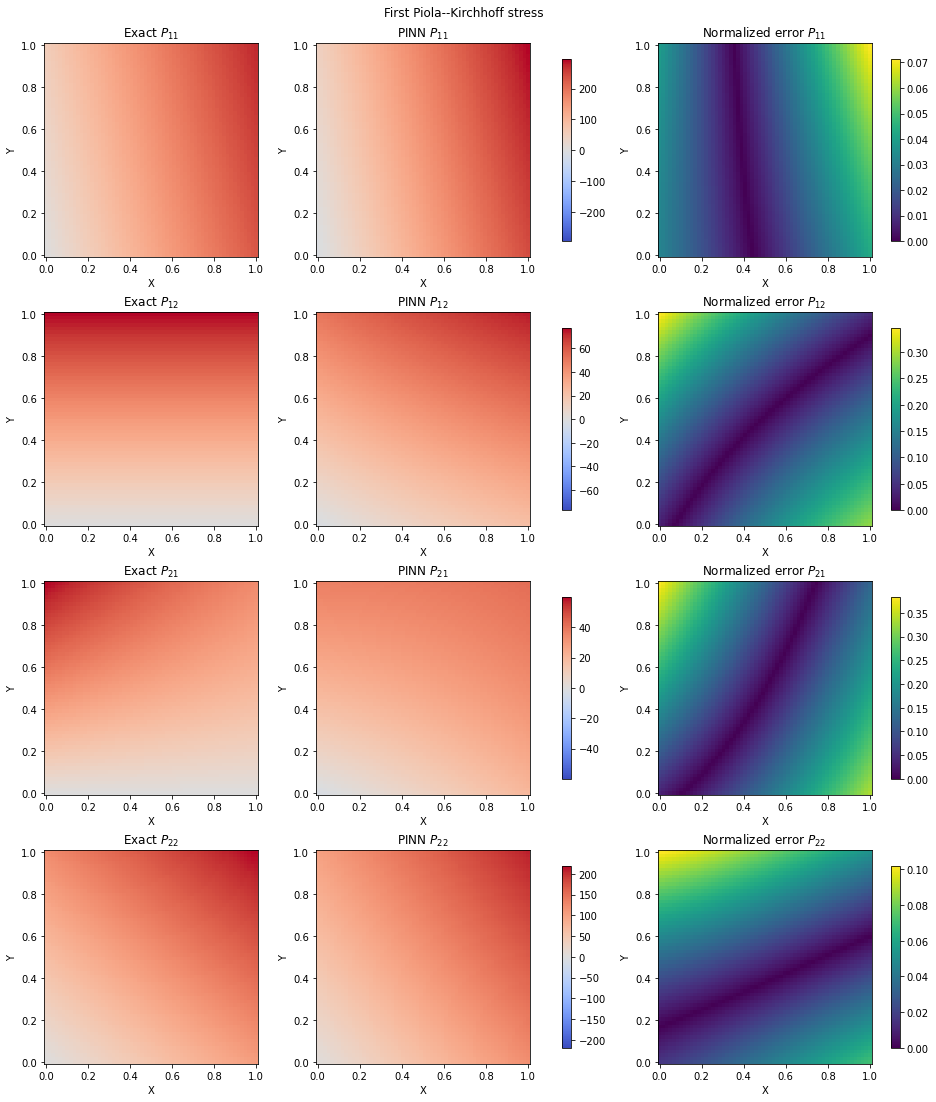

In [63]:
plot_solution()


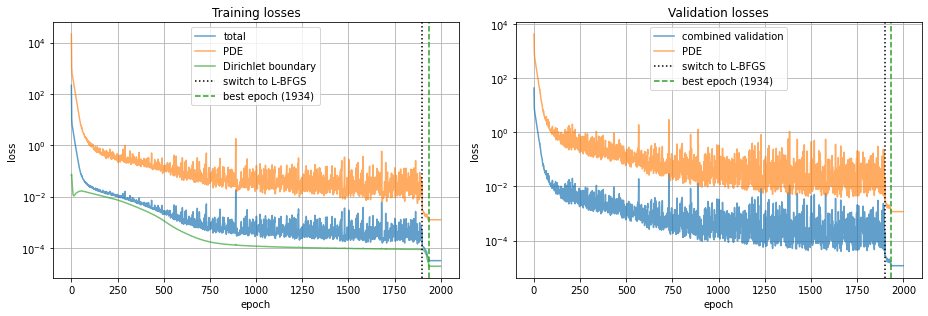

In [64]:
plot_losses()


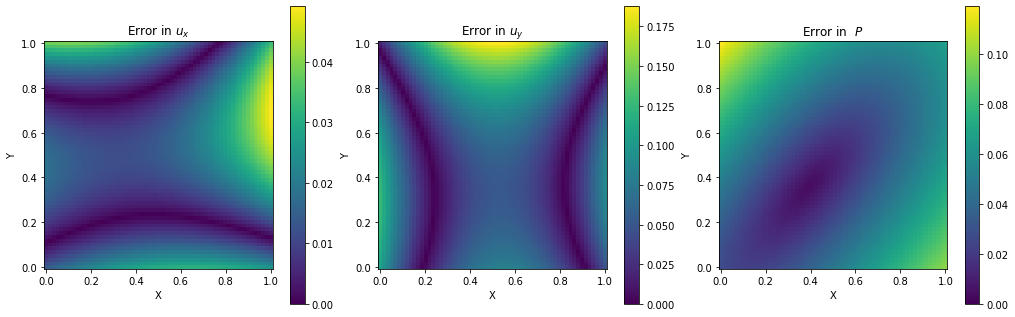

In [65]:
plot_errors()
